✅ Archivo cargado con éxito en la sesión de Colab.

Conteo de admitidos (1) vs no admitidos (0):
Admitted
1    327
0     73
Name: count, dtype: int64

--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

           0       0.78      0.41      0.54        17
           1       0.86      0.97      0.91        63

    accuracy                           0.85        80
   macro avg       0.82      0.69      0.72        80
weighted avg       0.84      0.85      0.83        80



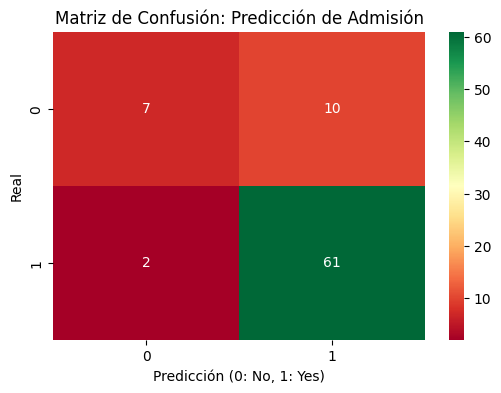

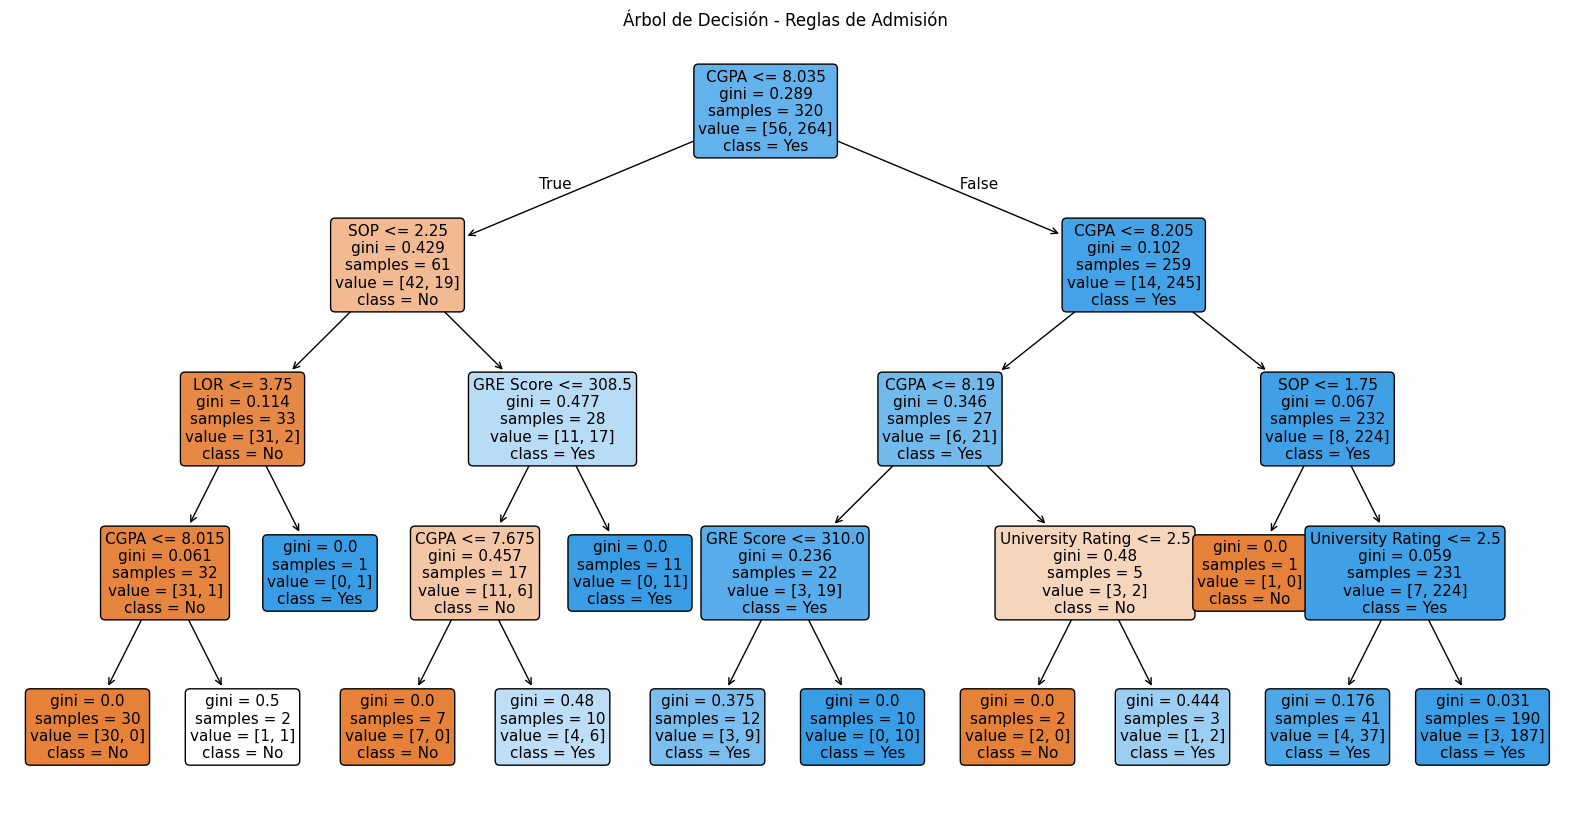

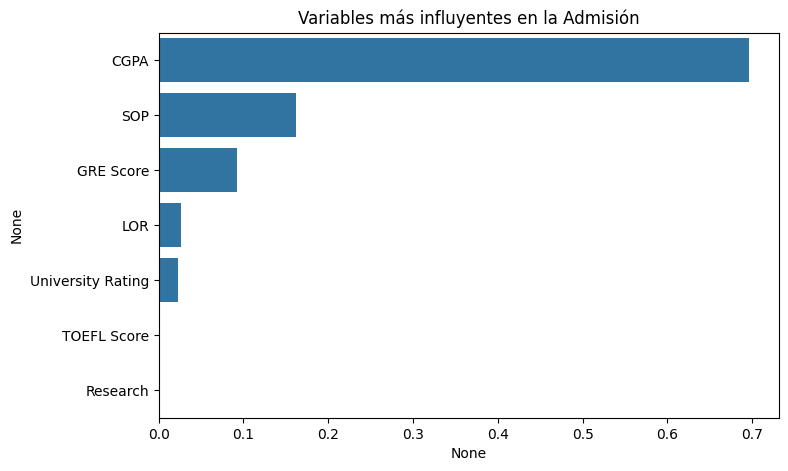

In [2]:
# =========================================================
# LABORATORIO: Modelo sencillo mediante árboles de clasificación en Python
# Objetivo General: Aplicar uno o varios algoritmos de clasificación para predecir la variable respuesta en el conjunto de datos objetivo, evaluar dicho algoritmo e interpretar los resultados
# Objetivo Específico: Predecir si un alumno es admitido (Yes/No)
# Regla de Negocio: Chance of Admit >= 0.6 es "Yes"
# ESTUDIANTE: Eivar Solis Tulande
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---------------------------------------------------------
# 1. CARGA DEL DATASET
# ---------------------------------------------------------

nombre_archivo = "Admission_Predict.csv"

try:
    df = pd.read_csv(nombre_archivo)
    df.columns = df.columns.str.strip()
    print("✅ Archivo cargado con éxito en la sesión de Colab.")
except FileNotFoundError:
    print("❌ ERROR: No se encuentra el archivo en Colab.")
    print("Por favor, arrastra 'Admission_Predict.csv' al panel de archivos (izquierda).")

# ---------------------------------------------------------
# 2. TRANSFORMACIÓN DE VARIABLE (REGLA 0.6)
# ---------------------------------------------------------

df['Admitted'] = np.where(df['Chance of Admit'] >= 0.6, 1, 0)

print(f"\nConteo de admitidos (1) vs no admitidos (0):\n{df['Admitted'].value_counts()}")

# ---------------------------------------------------------
# 3. SELECCIÓN DE VARIABLES Y DIVISIÓN TRAIN/TEST
# ---------------------------------------------------------

X = df.drop(['Serial No.', 'Chance of Admit', 'Admitted'], axis=1)
y = df['Admitted']

# División: 80% para entrenar, 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# ---------------------------------------------------------
# 4. MODELO: ÁRBOL DE CLASIFICACIÓN
# ---------------------------------------------------------

# Se procede a usar un árbol con profundidad 4 para que sea legible y preciso
clf = DecisionTreeClassifier(max_depth=4, criterion='gini', random_state=42)
clf.fit(X_train, y_train)

# Predicción

y_pred = clf.predict(X_test)

# ---------------------------------------------------------
# 5. RESULTADOS Y VISUALIZACIÓN
# ---------------------------------------------------------

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred))

# Matriz de Confusión

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='RdYlGn')
plt.title("Matriz de Confusión: Predicción de Admisión")
plt.xlabel("Predicción (0: No, 1: Yes)")
plt.ylabel("Real")
plt.show()

# Visualización del Árbol (Parte estructural del Laboratorio)

plt.figure(figsize=(20,10))
plot_tree(clf, feature_names=X.columns, class_names=['No', 'Yes'], filled=True, rounded=True, fontsize=11)
plt.title("Árbol de Decisión - Reglas de Admisión")
plt.show()

# Importancia de Variables

importancias = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importancias, y=importancias.index)
plt.title("Variables más influyentes en la Admisión")
plt.show()
